In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
import seaborn as sns

In [2]:
demo_raw = pd.read_csv("../data/BlackFriday-Demographic.csv")
click_raw = pd.read_csv("../data/Click_Button.csv")
purchase_raw = pd.read_csv("../data/Purchases.csv")

print("Raw demographic shape:", demo_raw.shape)
print("Raw clickstream shape:", click_raw.shape)
print("Raw purchase shape:", purchase_raw.shape)

Raw demographic shape: (233599, 11)
Raw clickstream shape: (12330, 18)
Raw purchase shape: (74817, 7)


In [3]:
demo = demo_raw.copy()
demo.columns = demo.columns.str.strip()

demo = demo.drop(columns=["User_ID", "Product_ID"], errors="ignore")

for col in ["Product_Category_2", "Product_Category_3"]:
    if col in demo.columns:
        demo[col] = demo[col].fillna(0)

demo = demo.drop_duplicates()

print("Clean demographic shape:", demo.shape)
display(demo.head())

Clean demographic shape: (91628, 9)


,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,M,46-50,7,B,2,1,1,11.0,0.0
1,M,26-35,17,C,0,0,3,5.0,0.0
2,F,36-45,1,B,4+,1,5,14.0,0.0
3,F,36-45,1,B,4+,1,4,9.0,0.0
4,F,26-35,1,C,1,0,4,5.0,12.0


In [4]:
click = click_raw.copy()
click.columns = click.columns.str.strip()

click = click.drop(columns=["Revenue"], errors="ignore")

if "Weekend" in click.columns:
    click["Weekend"] = click["Weekend"].astype(int)

click = click.drop_duplicates()

print("Clean clickstream shape:", click.shape)
display(click.head())

Clean clickstream shape: (12205, 17)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1


^^The rows and columns we have before and after cleaning the dataset and after pca

In [5]:
purchase = purchase_raw.copy()
purchase.columns = purchase.columns.str.strip()

if "Timestamp" in purchase.columns:
    purchase["Timestamp"] = pd.to_datetime(purchase["Timestamp"], errors="coerce")
    purchase["hour"] = purchase["Timestamp"].dt.hour
    purchase["day_of_week"] = purchase["Timestamp"].dt.dayofweek
    purchase = purchase.drop(columns=["Timestamp"])

purchase = purchase.drop_duplicates()

user_col = None
for possible in ["UserID", "User_ID", "user_id", "UserId"]:
    if possible in purchase.columns:
        user_col = possible
        break

if user_col is None:
    purchase["row_id"] = range(len(purchase))
    user_col = "row_id"

purchase_agg = purchase.groupby(user_col).agg({
    "Amount": ["mean", "sum", "count"],
    "hour": "mean",
    "day_of_week": "mean"
})

purchase_agg.columns = ["Amount_mean", "Amount_sum", "Amount_count", "avg_hour", "avg_day_of_week"]
purchase_agg = purchase_agg.reset_index(drop=True)

print("Clean purchase aggregate shape:", purchase_agg.shape)
display(purchase_agg.head())

Clean purchase aggregate shape: (1000, 5)


,Amount_mean,Amount_sum,Amount_count,avg_hour,avg_day_of_week
0,249.516097,1996.128780,8,13.890244,3.158537
1,205.888748,2676.553720,13,11.671233,3.287671
2,252.116565,1512.699392,6,13.406250,3.187500
3,258.091818,2322.826358,9,10.963855,3.048193
4,312.759478,2189.316345,7,11.785714,2.916667


In [6]:
demo_encoded = pd.get_dummies(demo, drop_first=True)
click_encoded = pd.get_dummies(click, drop_first=True)
purchase_encoded = pd.get_dummies(purchase_agg, drop_first=True)

demo_encoded = demo_encoded.replace([np.inf, -np.inf], np.nan).fillna(0)
click_encoded = click_encoded.replace([np.inf, -np.inf], np.nan).fillna(0)
purchase_encoded = purchase_encoded.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Encoded demographic shape:", demo_encoded.shape)
print("Encoded clickstream shape:", click_encoded.shape)
print("Encoded purchase shape:", purchase_encoded.shape)

Encoded demographic shape: (91628, 18)
Encoded clickstream shape: (12205, 26)
Encoded purchase shape: (1000, 5)


In [7]:
demo_scaler = StandardScaler()
click_scaler = StandardScaler()
purchase_scaler = StandardScaler()

demo_scaled = demo_scaler.fit_transform(demo_encoded)
click_scaled = click_scaler.fit_transform(click_encoded)
purchase_scaled = purchase_scaler.fit_transform(purchase_encoded)

In [8]:
demo_pca_model = PCA(n_components=0.90, random_state=42)
click_pca_model = PCA(n_components=0.90, random_state=42)
purchase_pca_model = PCA(n_components=0.90, random_state=42)

demo_pca = demo_pca_model.fit_transform(demo_scaled)
click_pca = click_pca_model.fit_transform(click_scaled)
purchase_pca = purchase_pca_model.fit_transform(purchase_scaled)

print("Demographic PCA shape:", demo_pca.shape)
print("Clickstream PCA shape:", click_pca.shape)
print("Purchase PCA shape:", purchase_pca.shape)

Demographic PCA shape: (91628, 14)
Clickstream PCA shape: (12205, 19)
Purchase PCA shape: (1000, 4)



--- Predicting Purchase Intention (Clickstream) ---
Accuracy: 0.8546
F1-Score (Weighted): 0.8402

Detailed Report:
               precision    recall  f1-score   support

       False       0.89      0.95      0.92      2079
        True       0.52      0.32      0.40       362

    accuracy                           0.85      2441
   macro avg       0.70      0.64      0.66      2441
weighted avg       0.83      0.85      0.84      2441



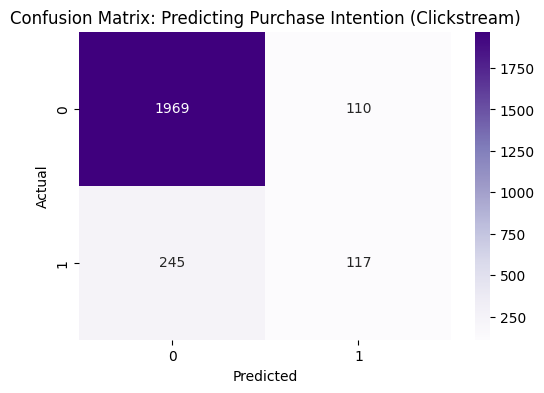


--- Predicting City Category (Demographics) ---
Accuracy: 0.9193
F1-Score (Weighted): 0.9190

Detailed Report:
               precision    recall  f1-score   support

           A       0.89      0.82      0.85      4534
           B       0.98      0.97      0.98      7172
           C       0.87      0.93      0.90      6620

    accuracy                           0.92     18326
   macro avg       0.92      0.91      0.91     18326
weighted avg       0.92      0.92      0.92     18326



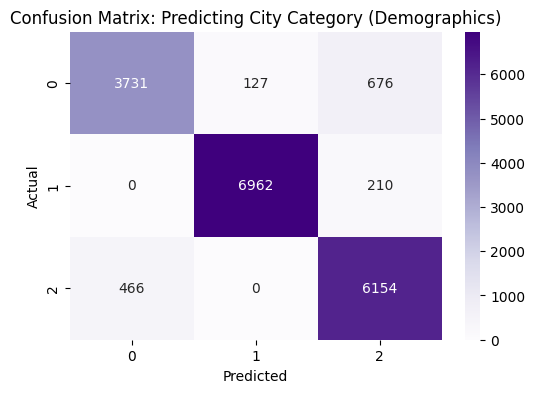

In [9]:
# NAIVE BAYES MODEL!
y_click = click_raw.loc[click.index, 'Revenue']
y_demo = demo_raw.loc[demo.index, 'City_Category']
def evaluate_nb_model(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    y_pred = nb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n--- {title} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score (Weighted): {f1:.4f}")
    print("\nDetailed Report:\n", classification_report(y_test, y_pred))
    
    # Plot Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_nb_model(click_pca, y_click, "Predicting Purchase Intention (Clickstream)")
evaluate_nb_model(demo_pca, y_demo, "Predicting City Category (Demographics)")



In [ ]:

def initialize_centroids(X, k, random_state=42):
    """K-Means++ init: spread initial centroids probabilistically."""
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    centroids = [X[rng.integers(n)]]
    for _ in range(1, k):
        dists = np.array([
            min(np.sum((x - c) ** 2) for c in centroids)
            for x in X
        ])
        probs = dists / dists.sum()
        centroids.append(X[rng.choice(n, p=probs)])
    return np.array(centroids)


def assign_clusters(X, centroids):
    """Assign each point to its nearest centroid."""
    dists = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(dists, axis=1)


def update_centroids(X, labels, k):
    """Recompute centroids as mean of all points in each cluster."""
    centroids = []
    for i in range(k):
        pts = X[labels == i]
        if len(pts) == 0:
            centroids.append(X[np.random.randint(X.shape[0])])
        else:
            centroids.append(pts.mean(axis=0))
    return np.array(centroids)


def calculate_wcss(X, labels, centroids):
    """Within-cluster sum of squares."""
    return sum(
        np.sum((X[labels == i] - centroids[i]) ** 2)
        for i in range(len(centroids))
    )


def manual_kmeans(X, k, random_state=42, max_iter=300, tol=1e-4):
    """K-Means loop: init -> assign -> update -> repeat until convergence."""
    centroids = initialize_centroids(X, k, random_state)
    for _ in range(max_iter):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        if np.linalg.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids
    labels = assign_clusters(X, centroids)
    wcss = calculate_wcss(X, labels, centroids)
    return labels, centroids, wcss


def run_kmeans_range(X, min_k=2, max_k=8):
    """Run manual K-Means for k=min_k..max_k, return WCSS and silhouette scores."""
    results = []
    for k in range(min_k, max_k + 1):
        labels, centroids, wcss = manual_kmeans(X, k, random_state=42)
        score = silhouette_score(X, labels)
        results.append({"k": k, "wcss": wcss, "silhouette": score})
    return pd.DataFrame(results)

In [11]:
demo_scores = run_kmeans_range(demo_pca)
click_scores = run_kmeans_range(click_pca)
purchase_scores = run_kmeans_range(purchase_pca)

print("Demographic scores")
display(demo_scores)

print("Clickstream scores")
display(click_scores)

print("Purchase scores")
display(purchase_scores)

Demographic scores


,k,wcss,silhouette
0,2,1.411499e+06,0.085629
1,3,1.321866e+06,0.159938
2,4,1.209490e+06,0.168328
3,5,1.086356e+06,0.175752
4,6,9.830955e+05,0.208411
5,7,9.730708e+05,0.175571
6,8,9.615336e+05,0.167417


Clickstream scores


,k,wcss,silhouette
0,2,267007.233080,0.187307
1,3,247944.920742,0.188579
2,4,236536.198169,0.201674
3,5,223555.870772,0.111896
4,6,218623.271211,0.127917
5,7,205478.444131,0.122578
6,8,192498.174672,0.153948


Purchase scores


,k,wcss,silhouette
0,2,3689.207991,0.232967
1,3,3171.638378,0.195327
2,4,2875.220440,0.178268
3,5,2588.308524,0.176362
4,6,2392.118490,0.169970
5,7,2265.222972,0.164355
6,8,2147.100353,0.159979


In [12]:
demo_k = int(demo_scores.sort_values("silhouette", ascending=False).iloc[0]["k"])
click_k = int(click_scores.sort_values("silhouette", ascending=False).iloc[0]["k"])
purchase_k = int(purchase_scores.sort_values("silhouette", ascending=False).iloc[0]["k"])

print("Chosen demographic k:", demo_k)
print("Chosen clickstream k:", click_k)
print("Chosen purchase k:", purchase_k)

demo_labels, demo_centroids, _ = manual_kmeans(demo_pca, demo_k, random_state=42)
click_labels, click_centroids, _ = manual_kmeans(click_pca, click_k, random_state=42)
purchase_labels, purchase_centroids, _ = manual_kmeans(purchase_pca, purchase_k, random_state=42)


Chosen demographic k: 6
Chosen clickstream k: 4
Chosen purchase k: 2


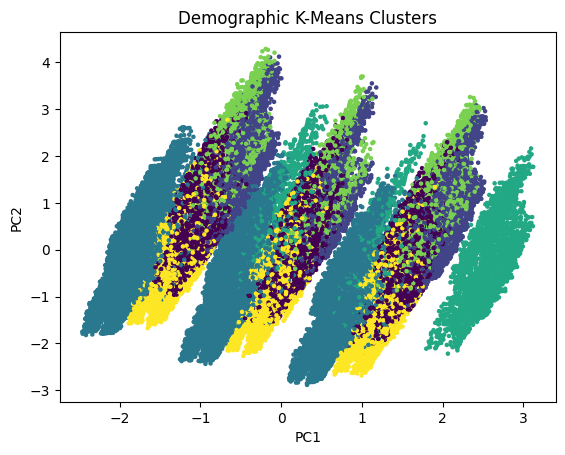

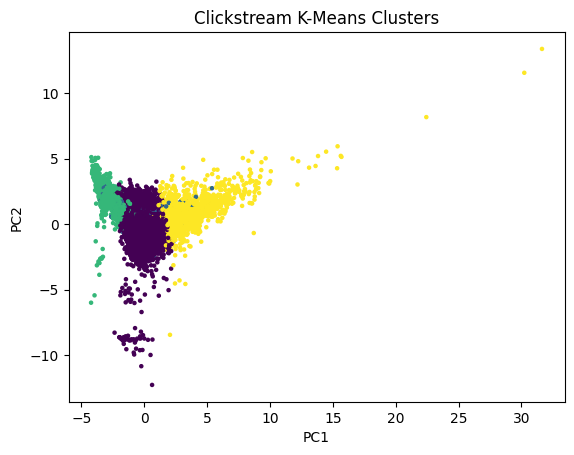

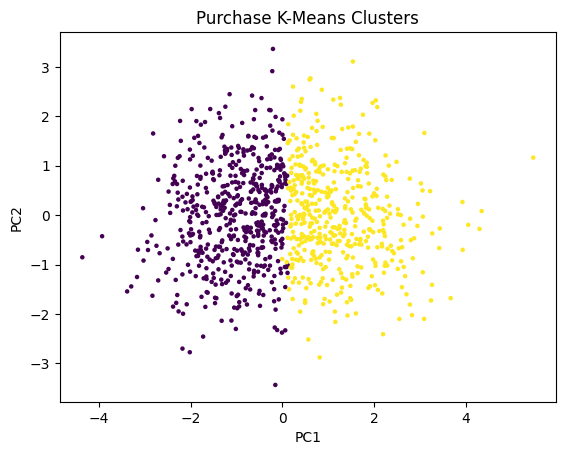

In [13]:
plt.figure()
plt.scatter(demo_pca[:, 0], demo_pca[:, 1], c=demo_labels, s=5)
plt.title("Demographic K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure()
plt.scatter(click_pca[:, 0], click_pca[:, 1], c=click_labels, s=5)
plt.title("Clickstream K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure()
plt.scatter(purchase_pca[:, 0], purchase_pca[:, 1], c=purchase_labels, s=5)
plt.title("Purchase K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [14]:
demo_labeled = demo.copy()
demo_labeled["cluster"] = demo_labels

click_labeled = click.copy()
click_labeled["cluster"] = click_labels

purchase_labeled = purchase_agg.copy()
purchase_labeled["cluster"] = purchase_labels

In [15]:
from features import FeatureEngineer
from modelmanager import ModelManager
from evaluator import Evaluator

fe = FeatureEngineer()
mm = ModelManager()
ev = Evaluator()

demo_clean = fe.clean_demographic(demo_raw)
demo_encoded = fe.encode(demo_clean)
demo_scaled, _ = mm.scale_data(demo_encoded)
demo_pca, _ = mm.apply_pca(demo_scaled)

best_model, labels, _ = mm.choose_best_kmeans(demo_pca, min_k=8, max_k=8) 
demo_clean['cluster'] = labels
demo_clean.to_csv("demographic_clustered.csv", index=False)
ev.cluster_profile(demo_clean, labels, "Demographics")


click_clean = fe.clean_clickstream(click_raw)
click_encoded = fe.encode(click_clean)
click_scaled, _ = mm.scale_data(click_encoded)
click_pca, _ = mm.apply_pca(click_scaled)

best_model, labels, _ = mm.choose_best_kmeans(click_pca, min_k=3, max_k=3)
click_clean['cluster'] = labels
click_clean.to_csv("clickstream_clustered.csv", index=False)
ev.cluster_profile(click_clean, labels, "Clickstream")


purchase_clean = fe.clean_purchases(purchase_raw)
purchase_agg = fe.aggregate_purchases(purchase_clean) 
purchase_encoded = fe.encode(purchase_agg)
purchase_scaled, _ = mm.scale_data(purchase_encoded)
purchase_pca, _ = mm.apply_pca(purchase_scaled)

best_model, labels, _ = mm.choose_best_kmeans(purchase_pca, min_k=2, max_k=2)
purchase_agg['cluster'] = labels
purchase_agg.to_csv("purchase_clustered.csv", index=False)
ev.cluster_profile(purchase_agg, labels, "Purchases")


===== DEMOGRAPHICS CLUSTER SIZES =====
cluster
0    11062
1     7993
2    10811
3    12665
4    22912
5     9084
6    12306
7     4795
Name: count, dtype: int64

===== DEMOGRAPHICS CLUSTER PROFILE =====
         Occupation  Marital_Status  Product_Category_1  Product_Category_2  \
cluster                                                                       
0          8.585789        0.359338            4.886729            8.303562   
1          8.752533        0.707369            5.182535            8.524459   
2          8.771621        0.389973            4.842198            8.365646   
3          8.781603        0.387525            4.992894            8.421082   
4          8.314682        0.400925            4.808266            8.360990   
5          8.519044        0.699362            5.169859            8.526970   
6          7.785308        0.275232            4.674468            8.127986   
7          9.276955        0.615641            5.434828            8.550574   

     

(         Amount_mean   Amount_sum  Amount_count  hour_mean  day_of_week_mean  \
 cluster                                                                        
 0         253.435302  2703.308404      10.67968  11.480263          2.961562   
 1         305.223365  3967.903742      13.00000  10.717949          3.038462   
 
          EventType_add_to_cart_count  EventType_click_count  \
 cluster                                                       
 0                          10.727728              10.602603   
 1                          18.000000              11.000000   
 
          EventType_login_count  EventType_logout_count  \
 cluster                                                  
 0                    10.536537               10.656657   
 1                     6.000000               12.000000   
 
          EventType_page_view_count  ...  ProductID_prod_9991_count  \
 cluster                             ...                              
 0                        10.782783 

In [16]:
import pandas as pd

df = pd.read_csv('demographic_clustered.csv')
numeric_summary = df.groupby('cluster').mean(numeric_only=True)

categorical_summary = df.groupby('cluster')[['Age', 'Gender', 'City_Category']].agg(lambda x: x.mode()[0])

cluster_profiles = pd.concat([categorical_summary, numeric_summary], axis=1)

print("--- CLUSTER PERSONA BREAKDOWN ---")
print(cluster_profiles)

--- CLUSTER PERSONA BREAKDOWN ---
           Age Gender City_Category  Occupation  Marital_Status  \
cluster                                                           
0        26-35      M             B    8.585789        0.359338   
1        51-55      M             B    8.752533        0.707369   
2        26-35      M             B    8.771621        0.389973   
3        36-45      M             B    8.781603        0.387525   
4        26-35      M             B    8.314682        0.400925   
5        46-50      M             C    8.519044        0.699362   
6        18-25      M             B    7.785308        0.275232   
7          55+      M             C    9.276955        0.615641   

         Product_Category_1  Product_Category_2  Product_Category_3  
cluster                                                              
0                  4.886729            8.303562            6.120955  
1                  5.182535            8.524459            5.699362  
2              

In [17]:
age_gender_profile = pd.crosstab(
    demo_labeled["cluster"],
    [demo_labeled["Gender"], demo_labeled["Age"]],
    normalize="index"
)

display(age_gender_profile)

Gender          F                                                             \
Age          0-17     18-25     26-35     36-45     46-50    51-55       55+   
cluster                                                                        
0        0.000000  0.000000  0.000000  0.289654  0.000000  0.00000  0.000000   
1        0.000000  0.000000  0.000000  0.000000  0.303611  0.00000  0.000000   
2        0.023035  0.000000  0.245794  0.000000  0.000000  0.00000  0.000000   
3        0.000000  0.000000  0.000000  0.000000  0.000000  0.00000  0.250052   
4        0.000000  0.000000  0.000000  0.000000  0.000000  0.26886  0.000000   
5        0.000000  0.264015  0.000000  0.000000  0.000000  0.00000  0.000000   

Gender          M                                                             
Age          0-17     18-25     26-35     36-45     46-50    51-55       55+  
cluster                                                                       
0        0.000000  0.000000  0.000000  0.710346  0.000000  0.00000  0.000000  
1        0.000000  0.000000  0.000000  0.000000  0.696389  0.00000  0.000000  
2        0.044518  0.000000  0.686653  0.000000  0.000000  0.00000  0.000000  
3        0.000000  0.000000  0.000000  0.000000  0.000000  0.00000  0.749948  
4        0.000000  0.000000  0.000000  0.000000  0.000000  0.73114  0.000000  
5        0.000000  0.735985  0.000000  0.000000  0.000000  0.00000  0.000000

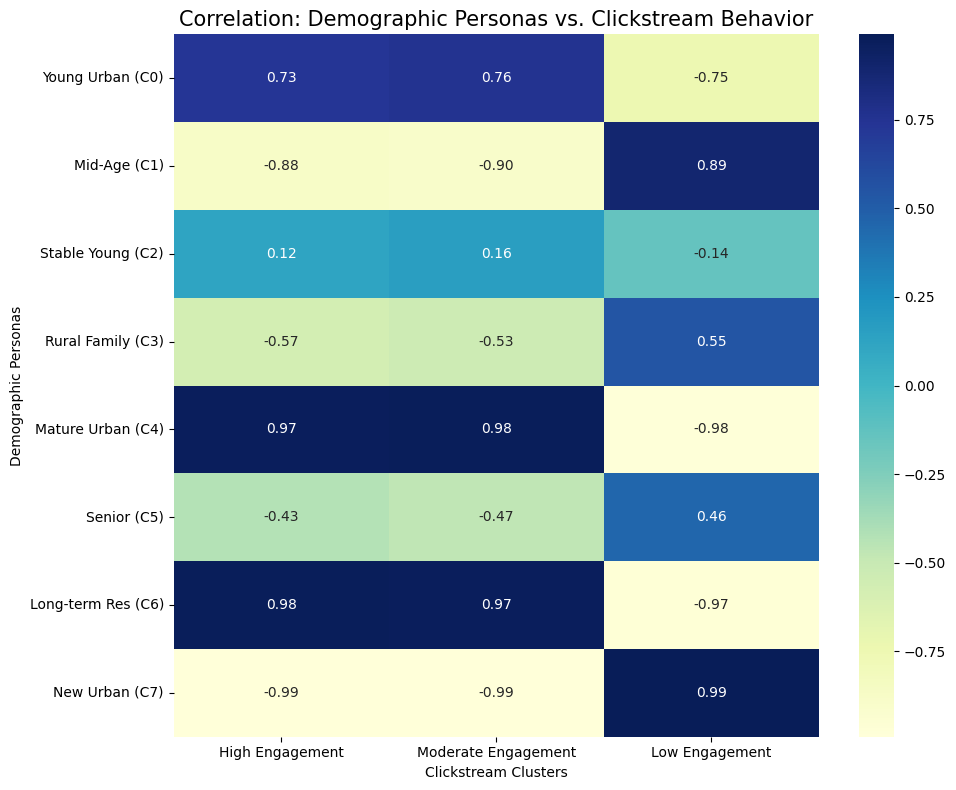

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

demo_df = pd.read_csv('demographic_clustered.csv')
click_df = pd.read_csv('clickstream_clustered.csv')

demo_profile = demo_df.groupby('cluster').mean(numeric_only=True)
click_profile = click_df.groupby('cluster').mean(numeric_only=True)

pca = PCA(n_components=3)
demo_reduced = pca.fit_transform(demo_profile)
click_reduced = pca.fit_transform(click_profile)

matrix_values = cosine_similarity(demo_reduced, click_reduced)
demo_labels = [
    "Young Urban (C0)", "Mid-Age (C1)", "Stable Young (C2)", 
    "Rural Family (C3)", "Mature Urban (C4)", "Senior (C5)", 
    "Long-term Res (C6)", "New Urban (C7)"
]
plt.figure(figsize=(10, 8))

sns.heatmap(matrix_values[:, :3], 
            annot=True, 
            cmap='YlGnBu', 
            xticklabels=['High Engagement', 'Moderate Engagement', 'Low Engagement'],
            yticklabels=demo_labels,
            fmt=".2f")
plt.title("Correlation: Demographic Personas vs. Clickstream Behavior", fontsize=15)
plt.xlabel("Clickstream Clusters")
plt.ylabel("Demographic Personas")
plt.tight_layout()
plt.show()

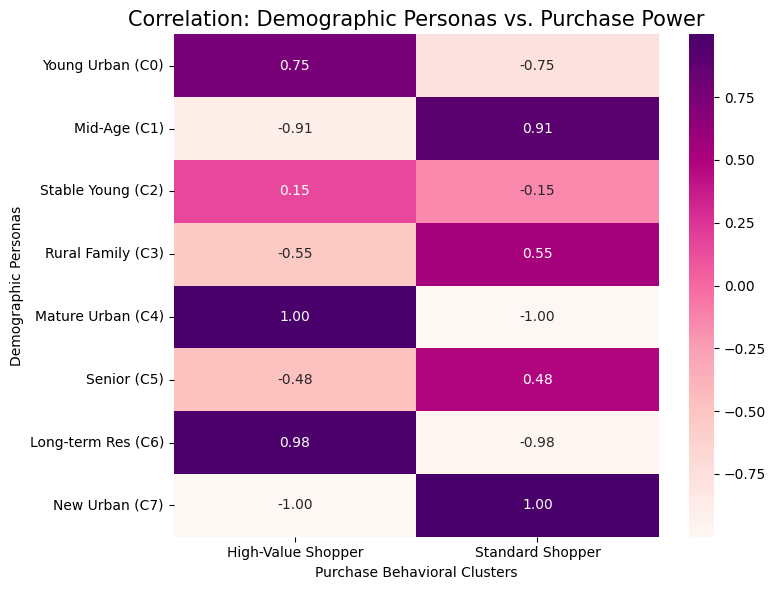

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

demo_df = pd.read_csv('demographic_clustered.csv')
purchase_df = pd.read_csv('purchase_clustered.csv')

# group into centroids
demo_profile = demo_df.groupby('cluster').mean(numeric_only=True)
purchase_profile = purchase_df.groupby('cluster').mean(numeric_only=True)

pca = PCA(n_components=2)
demo_reduced = pca.fit_transform(demo_profile)
purchase_reduced = pca.fit_transform(purchase_profile)

matrix_values = cosine_similarity(demo_reduced, purchase_reduced)

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_values, 
            annot=True, 
            cmap='RdPu', 
            xticklabels=['High-Value Shopper', 'Standard Shopper'],
            yticklabels=demo_labels, 
            fmt=".2f")

plt.title("Correlation: Demographic Personas vs. Purchase Power", fontsize=15)
plt.xlabel("Purchase Behavioral Clusters")
plt.ylabel("Demographic Personas")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.stats import mode
import numpy as np

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(demo_pca)

y_true = demo_raw.loc[demo.index, 'City_Category']

def map_clusters_to_labels(clusters, y_true):
    labels = np.zeros_like(clusters, dtype=object)
    
    # Loop through each unique cluster found by K-Means
    for i in np.unique(clusters):
        mask = (clusters == i)
        if np.any(mask):
            most_frequent_label = y_true[mask].value_counts().idxmax()
            labels[mask] = most_frequent_label
    return labels

y_pred = map_clusters_to_labels(clusters, y_true)

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"K-Means Accuracy (after mapping): {accuracy:.4f}")
print(f"K-Means F1-Score (weighted): {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred))

K-Means Accuracy (after mapping): 0.3974
K-Means F1-Score (weighted): 0.3318


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Classification Report:
               precision    recall  f1-score   support

           A       0.00      0.00      0.00     22823
           B       0.40      0.36      0.38     35897
           C       0.40      0.71      0.51     32908

    accuracy                           0.40     91628
   macro avg       0.26      0.36      0.30     91628
weighted avg       0.30      0.40      0.33     91628



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
